In [2]:
!pip install wfdb numpy pandas matplotlib scipy PyWavelets scikit-learn


In [3]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
DATA_PATH = "../data/mit-bih-arrhythmia-database-1.0.0"

print("Dataset path:", DATA_PATH)

RECORD = "100"

record = wfdb.rdrecord(
    f"{DATA_PATH}/{RECORD}"
)

annotation = wfdb.rdann(
    f"{DATA_PATH}/{RECORD}",
    "atr"
)


Dataset path: ../data/mit-bih-arrhythmia-database-1.0.0


In [5]:
print("========== ECG RECORD INFORMATION ==========")

print("Record ID:", RECORD)

# Sampling frequency = measurements recorded per second
print("Sampling frequency:", record.fs, "Hz")

# Number of ECG channels
print("Number of channels:", record.n_sig)

# Total number of time samples
print("Number of samples:", record.sig_len)

# Shape of the ECG matrix
print("Signal shape:", record.p_signal.shape)

# Names of the ECG channels/leads
print("Channel names:", record.sig_name)

========== ECG RECORD INFORMATION ==========
Record ID: 100
Sampling frequency: 360 Hz
Number of channels: 2
Number of samples: 650000
Signal shape: (650000, 2)
Channel names: ['MLII', 'V5']


In [6]:
duration_seconds = record.sig_len / record.fs
duration_minutes = duration_seconds / 60

print("Duration in seconds:", duration_seconds)
print("Duration in minutes:", duration_minutes)

Duration in seconds: 1805.5555555555557
Duration in minutes: 30.092592592592595


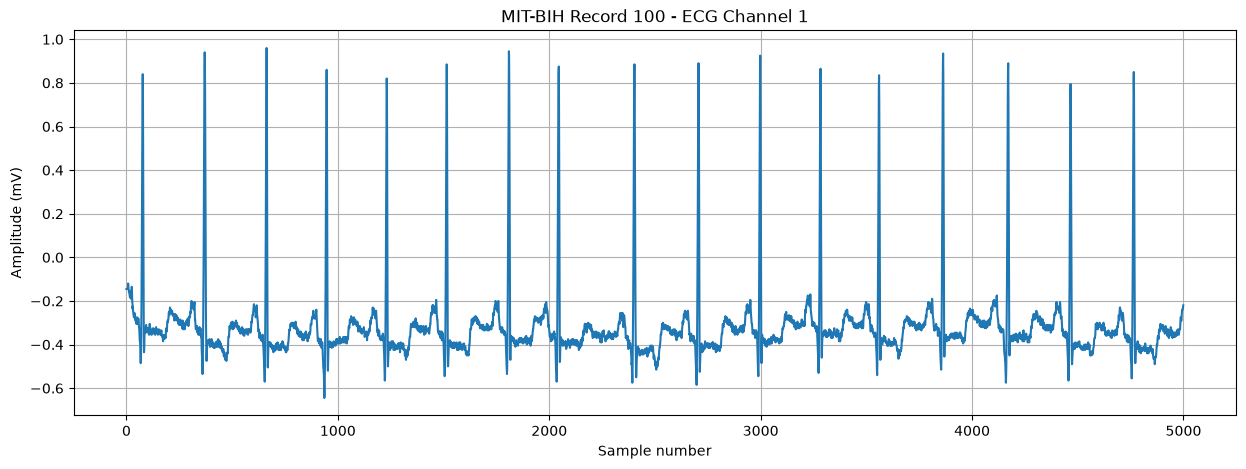

In [7]:
NUM_SAMPLES_TO_PLOT = 5000

plt.figure(figsize=(15, 5))

plt.plot(
    record.p_signal[:NUM_SAMPLES_TO_PLOT, 0]
)

plt.xlabel("Sample number")
plt.ylabel("Amplitude (mV)")
plt.title(f"MIT-BIH Record {RECORD} - ECG Channel 1")

plt.grid(True)
plt.show()

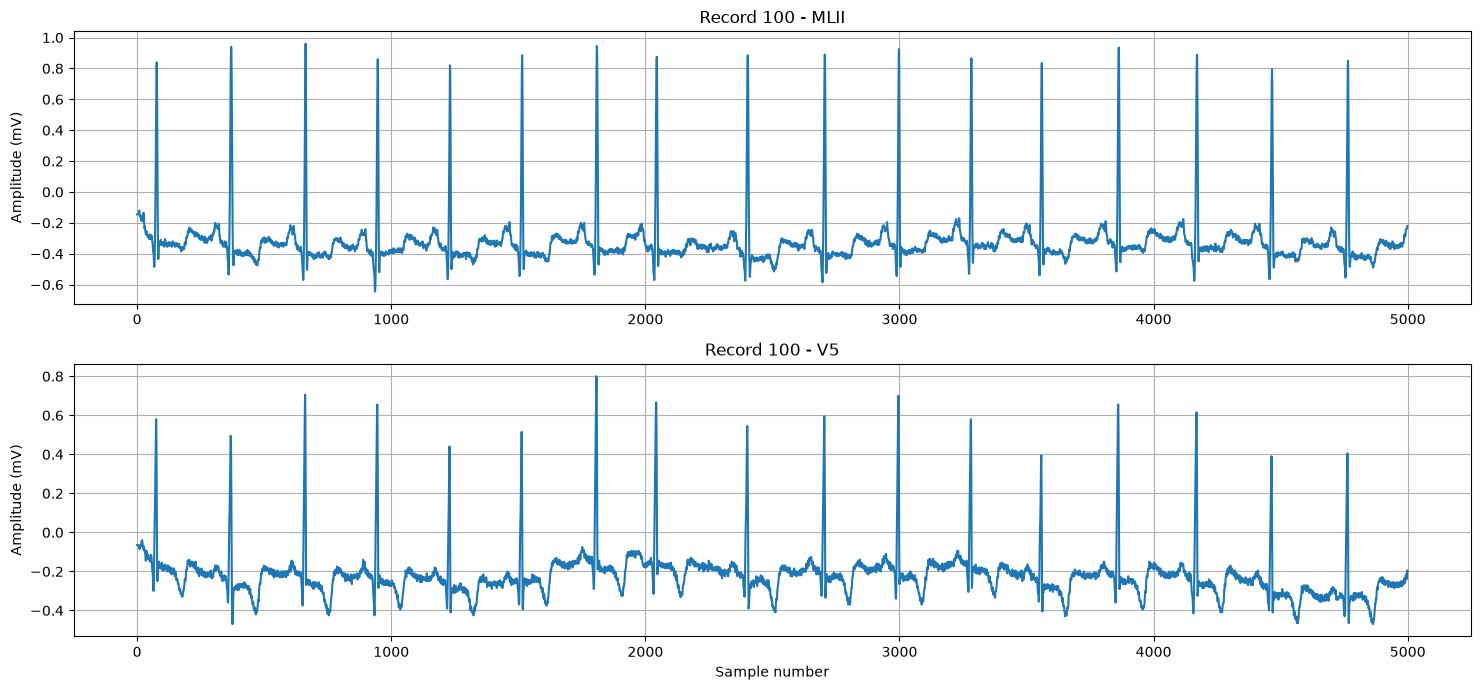

In [8]:
NUM_SAMPLES_TO_PLOT = 5000

plt.figure(figsize=(15, 7))

plt.subplot(2, 1, 1)

plt.plot(
    record.p_signal[:NUM_SAMPLES_TO_PLOT, 0]
)

plt.title(f"Record {RECORD} - {record.sig_name[0]}")
plt.ylabel("Amplitude (mV)")
plt.grid(True)

plt.subplot(2, 1, 2)

plt.plot(
    record.p_signal[:NUM_SAMPLES_TO_PLOT, 1]
)

plt.title(f"Record {RECORD} - {record.sig_name[1]}")
plt.xlabel("Sample number")
plt.ylabel("Amplitude (mV)")
plt.grid(True)


plt.tight_layout()
plt.show()

In [9]:
print("========== ANNOTATION INFORMATION ==========")

print("Number of annotations:", len(annotation.sample))

print("\nFirst 20 annotation positions:")
print(annotation.sample[:20])

print("\nFirst 20 annotation symbols:")
print(annotation.symbol[:20])

========== ANNOTATION INFORMATION ==========
Number of annotations: 2274

First 20 annotation positions:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]

First 20 annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [10]:

symbol_counts = pd.Series(
    annotation.symbol
).value_counts()

print(symbol_counts)

N    2239
A      33
+       1
V       1
Name: count, dtype: int64


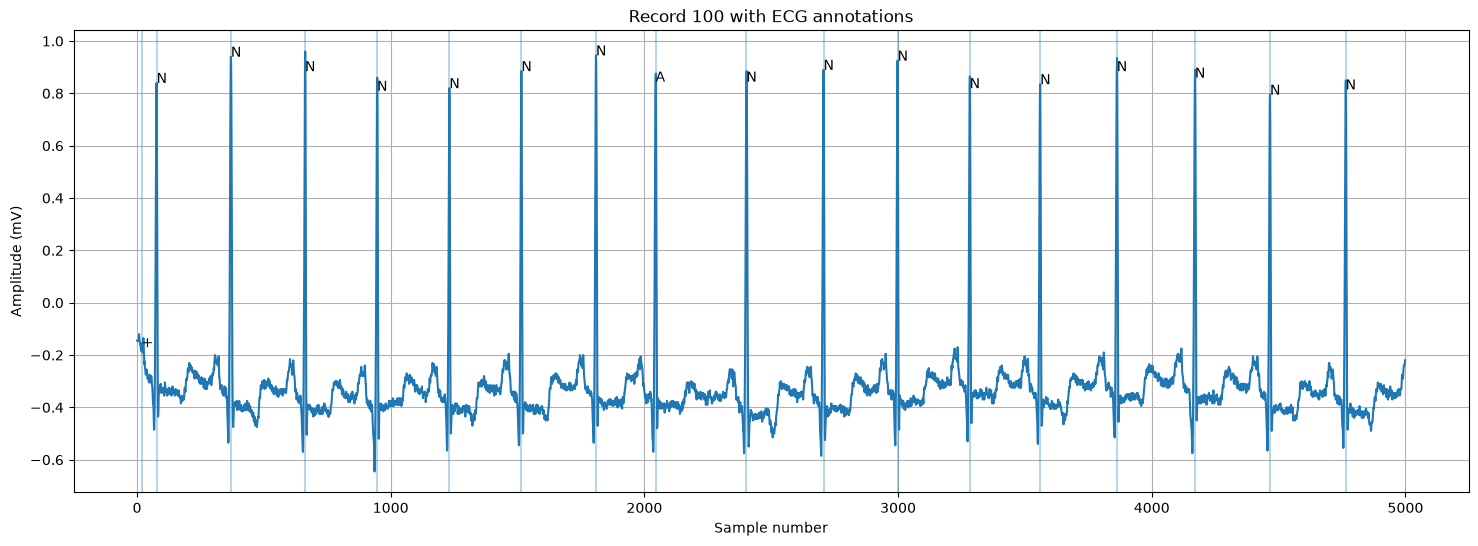

In [11]:
START = 0
END = 5000

signal = record.p_signal[:, 0]

plt.figure(figsize=(18, 6))


plt.plot(
    np.arange(START, END),
    signal[START:END],
    label="ECG"
)


for sample, symbol in zip(
    annotation.sample,
    annotation.symbol
):

    if START <= sample < END:


        plt.axvline(
            sample,
            alpha=0.3
        )
        plt.text(
            sample,
            signal[sample],
            symbol,
            fontsize=10
        )

plt.xlabel("Sample number")
plt.ylabel("Amplitude (mV)")
plt.title(f"Record {RECORD} with ECG annotations")

plt.grid(True)
plt.show()

In [12]:

print("First 10 annotations:\n")

for i in range(10):

    sample_position = annotation.sample[i]
    symbol = annotation.symbol[i]

    print(
        f"Annotation {i}: "
        f"sample = {sample_position}, "
        f"symbol = {symbol}"
    )

First 10 annotations:

Annotation 0: sample = 18, symbol = +
Annotation 1: sample = 77, symbol = N
Annotation 2: sample = 370, symbol = N
Annotation 3: sample = 662, symbol = N
Annotation 4: sample = 946, symbol = N
Annotation 5: sample = 1231, symbol = N
Annotation 6: sample = 1515, symbol = N
Annotation 7: sample = 1809, symbol = N
Annotation 8: sample = 2044, symbol = A
Annotation 9: sample = 2402, symbol = N


In [13]:

record_summary = pd.DataFrame({
    "Record": [RECORD],
    "Sampling_Frequency_Hz": [record.fs],
    "Channels": [record.n_sig],
    "Total_Samples": [record.sig_len],
    "Duration_Minutes": [duration_minutes],
    "Number_of_Annotations": [len(annotation.sample)]
})

record_summary

,Record,Sampling_Frequency_Hz,Channels,Total_Samples,Duration_Minutes,Number_of_Annotations
0,100,360,2,650000,30.092593,2274


In [14]:
print("        MIT-BIH RECORD 100 SUMMARY\n")


print(f"Record ID           : {RECORD}")
print(f"Sampling frequency  : {record.fs} Hz")
print(f"Channels            : {record.n_sig}")
print(f"Channel names       : {record.sig_name}")
print(f"Total samples       : {record.sig_len}")
print(f"Duration            : {duration_minutes:.2f} minutes")
print(f"Annotations         : {len(annotation.sample)}")



        MIT-BIH RECORD 100 SUMMARY

Record ID           : 100
Sampling frequency  : 360 Hz
Channels            : 2
Channel names       : ['MLII', 'V5']
Total samples       : 650000
Duration            : 30.09 minutes
Annotations         : 2274


In [16]:
symbol_counts = pd.Series(annotation.symbol).value_counts()

print("========== ANNOTATION SYMBOL COUNTS ==========")
print(symbol_counts)

print("========== UNIQUE ANNOTATION SYMBOLS ==========")

unique_symbols = sorted(set(annotation.symbol))

print(unique_symbols)
print("Number of unique symbols:", len(unique_symbols))
for symbol in unique_symbols:
    count = annotation.symbol.count(symbol)
    print(f"{symbol!r} : {count}")

========== ANNOTATION SYMBOL COUNTS ==========
N    2239
A      33
+       1
V       1
Name: count, dtype: int64
========== UNIQUE ANNOTATION SYMBOLS ==========
['+', 'A', 'N', 'V']
Number of unique symbols: 4
'+' : 1
'A' : 33
'N' : 2239
'V' : 1


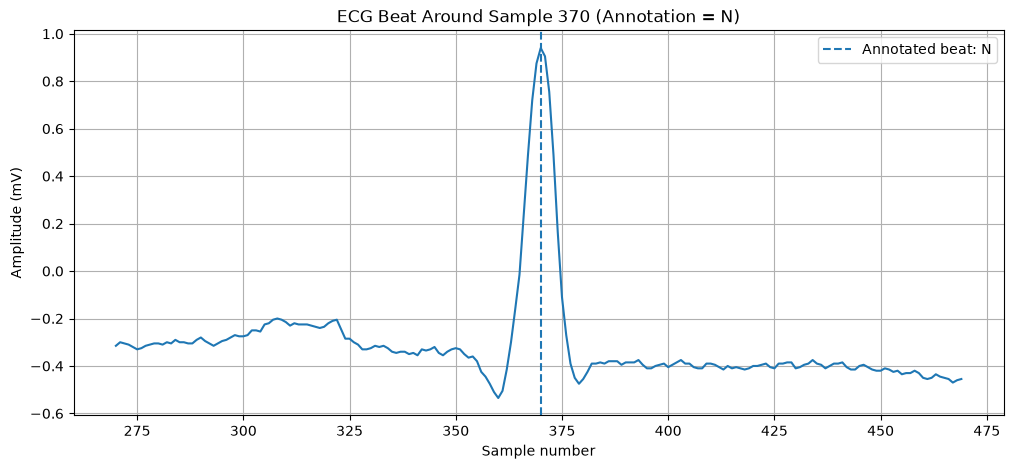

In [17]:
BEAT_INDEX = 2

beat_sample = annotation.sample[BEAT_INDEX]
beat_symbol = annotation.symbol[BEAT_INDEX]

WINDOW_BEFORE = 100
WINDOW_AFTER = 100

start = beat_sample - WINDOW_BEFORE
end = beat_sample + WINDOW_AFTER

ecg_segment = record.p_signal[start:end, 0]

plt.figure(figsize=(12, 5))

plt.plot(
    np.arange(start, end),
    ecg_segment
)

plt.axvline(
    beat_sample,
    linestyle="--",
    label=f"Annotated beat: {beat_symbol}"
)

plt.xlabel("Sample number")
plt.ylabel("Amplitude (mV)")
plt.title(
    f"ECG Beat Around Sample {beat_sample} "
    f"(Annotation = {beat_symbol})"
)

plt.legend()
plt.grid(True)
plt.show()

In [18]:
import os

# Find all MIT-BIH record IDs
record_ids = sorted([
    filename.replace(".hea", "")
    for filename in os.listdir(DATA_PATH)
    if filename.endswith(".hea")
])

print("Number of records:", len(record_ids))
print()
print("Record IDs:")
print(record_ids)

Number of records: 48

Record IDs:
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [19]:
all_record_stats = []

for record_id in record_ids:


    annotation = wfdb.rdann(
        f"{DATA_PATH}/{record_id}",
        "atr"
    )

    # Count every annotation symbol in this record
    symbol_counts = pd.Series(annotation.symbol).value_counts()

    # Store the information we care about
    all_record_stats.append({
        "Record": record_id,
        "Total_Annotations": len(annotation.symbol),
        "N": symbol_counts.get("N", 0),
        "A": symbol_counts.get("A", 0),
        "V": symbol_counts.get("V", 0),
        "F": symbol_counts.get("F", 0),
        "Other": sum(
            count
            for symbol, count in symbol_counts.items()
            if symbol not in ["N", "A", "V", "F"]
        )
    })

# Convert list of dictionaries into a DataFrame
annotation_summary = pd.DataFrame(all_record_stats)

print("========== ALL RECORDS ANNOTATION SUMMARY ==========")

display(annotation_summary)

========== ALL RECORDS ANNOTATION SUMMARY ==========


,Record,Total_Annotations,N,A,V,F,Other
0,100,2274,2239,33,1,0,1
1,101,1874,1860,3,0,0,11
2,102,2192,99,0,4,0,2089
3,103,2091,2082,2,0,0,7
4,104,2311,163,0,2,0,2146
5,105,2691,2526,0,41,0,124
6,106,2098,1507,0,520,0,71
7,107,2140,0,0,59,0,2081
8,108,1824,1739,4,17,2,62
9,109,2535,0,0,38,2,2495


In [20]:
print("========== TOTALS ACROSS ALL 48 RECORDS ==========")

print("Total annotations:", annotation_summary["Total_Annotations"].sum())
print("Total N:", annotation_summary["N"].sum())
print("Total A:", annotation_summary["A"].sum())
print("Total V:", annotation_summary["V"].sum())
print("Total F:", annotation_summary["F"].sum())
print("Total Other:", annotation_summary["Other"].sum())

========== TOTALS ACROSS ALL 48 RECORDS ==========
Total annotations: 112647
Total N: 75052
Total A: 2546
Total V: 7130
Total F: 803
Total Other: 27116


In [21]:
all_symbols = []

for record_id in record_ids:

    annotation = wfdb.rdann(
        f"{DATA_PATH}/{record_id}",
        "atr"
    )

    all_symbols.extend(annotation.symbol)

all_symbol_counts = pd.Series(all_symbols).value_counts()

print("========== ALL MIT-BIH ANNOTATION SYMBOLS ==========")
print()

for symbol, count in all_symbol_counts.items():
    print(f"{symbol!r:>5} : {count}")

print()
print("Number of unique symbols:", len(all_symbol_counts))

========== ALL MIT-BIH ANNOTATION SYMBOLS ==========

  'N' : 75052
  'L' : 8075
  'R' : 7259
  'V' : 7130
  '/' : 7028
  'A' : 2546
  '+' : 1291
  'f' : 982
  'F' : 803
  '~' : 616
  '!' : 472
  '"' : 437
  'j' : 229
  'x' : 193
  'a' : 150
  '|' : 132
  'E' : 106
  'J' : 83
  'Q' : 33
  'e' : 16
  '[' : 6
  ']' : 6
  'S' : 2

Number of unique symbols: 23


In [22]:
AAMI_MAPPING = {
    # N class: Normal and related beats
    "N": "N",
    "L": "N",
    "R": "N",
    "e": "N",
    "j": "N",

    # S class: Supraventricular beats
    "A": "S",
    "a": "S",
    "J": "S",
    "S": "S",

    # V class: Ventricular beats
    "V": "V",
    "E": "V",

    # F class: Fusion beats
    "F": "F",

    # Q class: Unknown / paced / other
    "/": "Q",
    "f": "Q",
    "Q": "Q"
}


# Show the mapping clearly
print("========== MIT-BIH → AAMI MAPPING ==========")

for symbol, aami_class in AAMI_MAPPING.items():
    print(f"{symbol!r}  →  {aami_class}")

========== MIT-BIH → AAMI MAPPING ==========
'N'  →  N
'L'  →  N
'R'  →  N
'e'  →  N
'j'  →  N
'A'  →  S
'a'  →  S
'J'  →  S
'S'  →  S
'V'  →  V
'E'  →  V
'F'  →  F
'/'  →  Q
'f'  →  Q
'Q'  →  Q
